<div style="background-color:#FFECB3; color:black; padding:10px; border-radius:5px;">

Entrainement du modèle de base avec la création de données augmentées

</div>

In [23]:
%%time
# Installations

# pip install tensorflow
# pip install Pillow
# pip install matplotlib

import time

# Bibliothèques principales
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import json

# TensorFlow et Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.utils import load_img

print(f"\n📦 Versions des bibliothèques :")
print(f"  - TensorFlow : {tf.__version__}")
print(f"  - Keras      : {keras.__version__}")
print(f"  - NumPy      : {np.__version__}")


📦 Versions des bibliothèques :
  - TensorFlow : 2.21.0
  - Keras      : 3.13.2
  - NumPy      : 2.4.3
CPU times: total: 0 ns
Wall time: 0 ns


<div style="background-color:#FFECB3; color:black; padding:10px; border-radius:5px;">

Test de cette version du modèle<br>

</div>

---------------------------------------
# Test
---------------------------------------

In [ ]:
%%time

# Préparation

def predict_image(model, image_path, class_names):
    
    # Charger et prétraiter l'image
    img = load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Ajouter dimension batch
    img_array = preprocess_input(img_array)  # Normalisation MobileNetV2
    
    # Prédire
    predictions = model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class_idx]
    
    # Top 3 prédictions
    top3_idx = np.argsort(predictions[0])[-3:][::-1]
    
    return {
        'predicted_class': class_names[predicted_class_idx],
        'confidence': confidence,
        'all_probabilities': predictions[0],
        'top3': [(class_names[i], predictions[0][i]) for i in top3_idx]
    }

print("✅ Fonction de prédiction créée !")

model_path = 'mobilenetv2_test1_finetuned.keras'
loaded_model = keras.models.load_model(model_path, compile=False)
print("✅ Modèle chargé !")

#class_names = ["00-normal", "01-minor", "02-moderate", "03-severe"]
with open("mobilenetv2_test1_finetuned_class_names.json", "r") as f:
    class_names = json.load(f)
print("class_names : ", class_names)


✅ Fonction de prédiction créée !
✅ Modèle chargé !
class_names :  ['00-normal', '01-minor', '02-moderate', '03-severe']
CPU times: total: 469 ms
Wall time: 459 ms


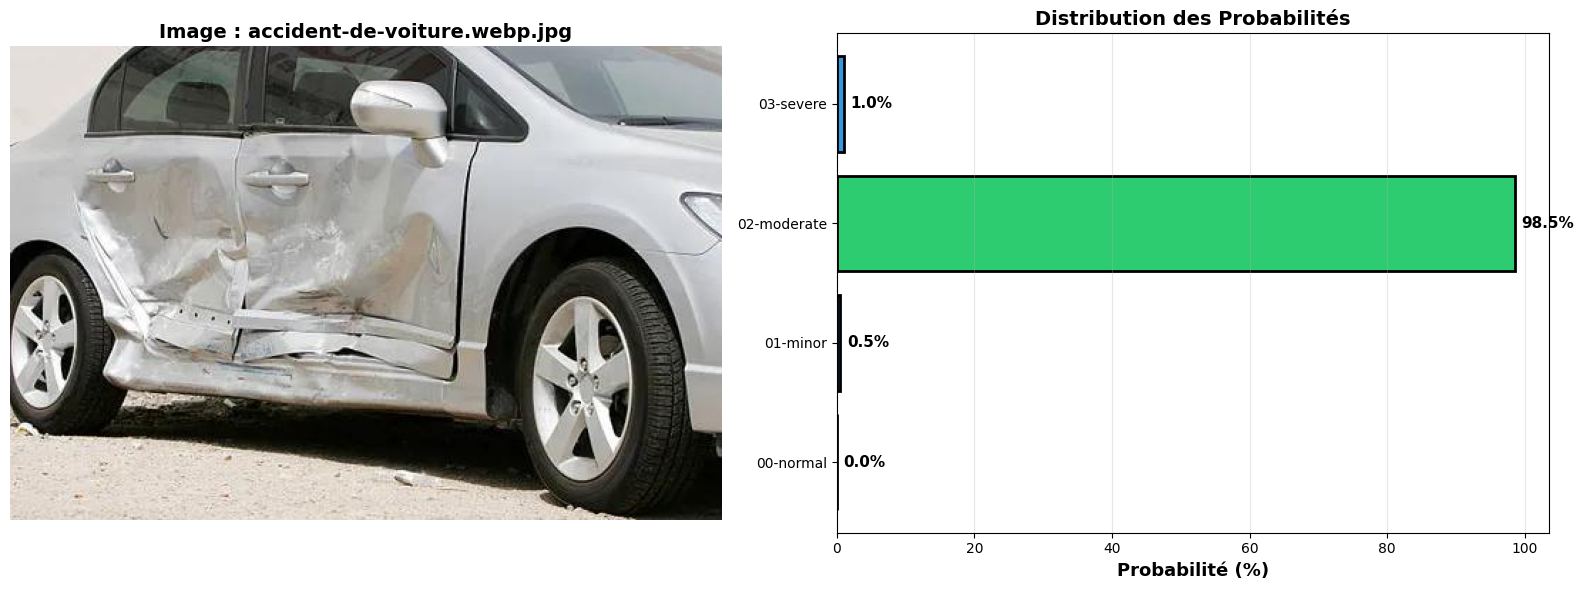


🔍 Analyse de la prédiction :
  - Classe prédite : 02-moderate
  - Confiance      : 98.53%

  - Top 3 prédictions :
    1. 02-moderate     : 98.53%
    2. 03-severe       : 1.01%
    3. 01-minor        : 0.46%
CPU times: total: 219 ms
Wall time: 189 ms


In [32]:
%%time


# Visualisation des probabilités pour une image

from PIL import Image

# Prendre une image spécifique
sample_image_path = "C:/Users/huber_otpq54a/OneDrive/Documents/Formation/IA/Developpement/Projets/Deep_Learning/Test/accident-de-voiture.webp"

im = Image.open(sample_image_path).convert("RGB")
sample_image_path = sample_image_path + ".jpg"
im.save(sample_image_path, "JPEG")

result = predict_image(loaded_model, sample_image_path, class_names)

# Visualiser
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Image
img = plt.imread(sample_image_path)
axes[0].imshow(img)
axes[0].axis('off')
axes[0].set_title(f"Image : {str(Path(sample_image_path).name)}", fontsize=14, fontweight='bold')

# Probabilités
probs = result['all_probabilities'] * 100
colors = ['#2ecc71' if i == np.argmax(probs) else '#3498db' for i in range(len(probs))]

bars = axes[1].barh(class_names, probs, color=colors, edgecolor='black', linewidth=2)
axes[1].set_xlabel('Probabilité (%)', fontsize=13, fontweight='bold')
axes[1].set_title('Distribution des Probabilités', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

# Ajouter les valeurs
for bar, prob in zip(bars, probs):
    width = bar.get_width()
    axes[1].text(width + 1, bar.get_y() + bar.get_height()/2.,
                f'{prob:.1f}%',
                ha='left', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n🔍 Analyse de la prédiction :")
print(f"  - Classe prédite : {result['predicted_class']}")
print(f"  - Confiance      : {result['confidence']*100:.2f}%")
print(f"\n  - Top 3 prédictions :")
for i, (cls, prob) in enumerate(result['top3'], 1):
    print(f"    {i}. {cls:15s} : {prob*100:.2f}%")